<a href="https://colab.research.google.com/github/192512041simats-hari/IOE-AND-AI-SYSTEM/blob/main/IOE%20EXP_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

===== IoT Smart Warehouse Safety Sensor Dataset =====

 Hour  Temperature(C)  Smoke_Density(ppm)  Gas_Level(ppm)  Humidity(%)  Alarm_Status
    0           29.97               14.10           304.5         61.9             0
    1           25.96               11.21           276.4         50.9             0
    2           25.99               15.67           323.5         48.4             0
    3           25.91               11.28           263.1         61.1             0
    4           23.58               22.47           237.6         65.5             0
    5           24.37               19.13           217.1         57.0             0
    6           24.10               19.06           182.6         62.0             0
    7           21.37               25.24           154.1         67.6             0
    8           25.58               17.61           104.3         31.6             0
    9           25.17               24.50           134.7         65.0             0
   10     

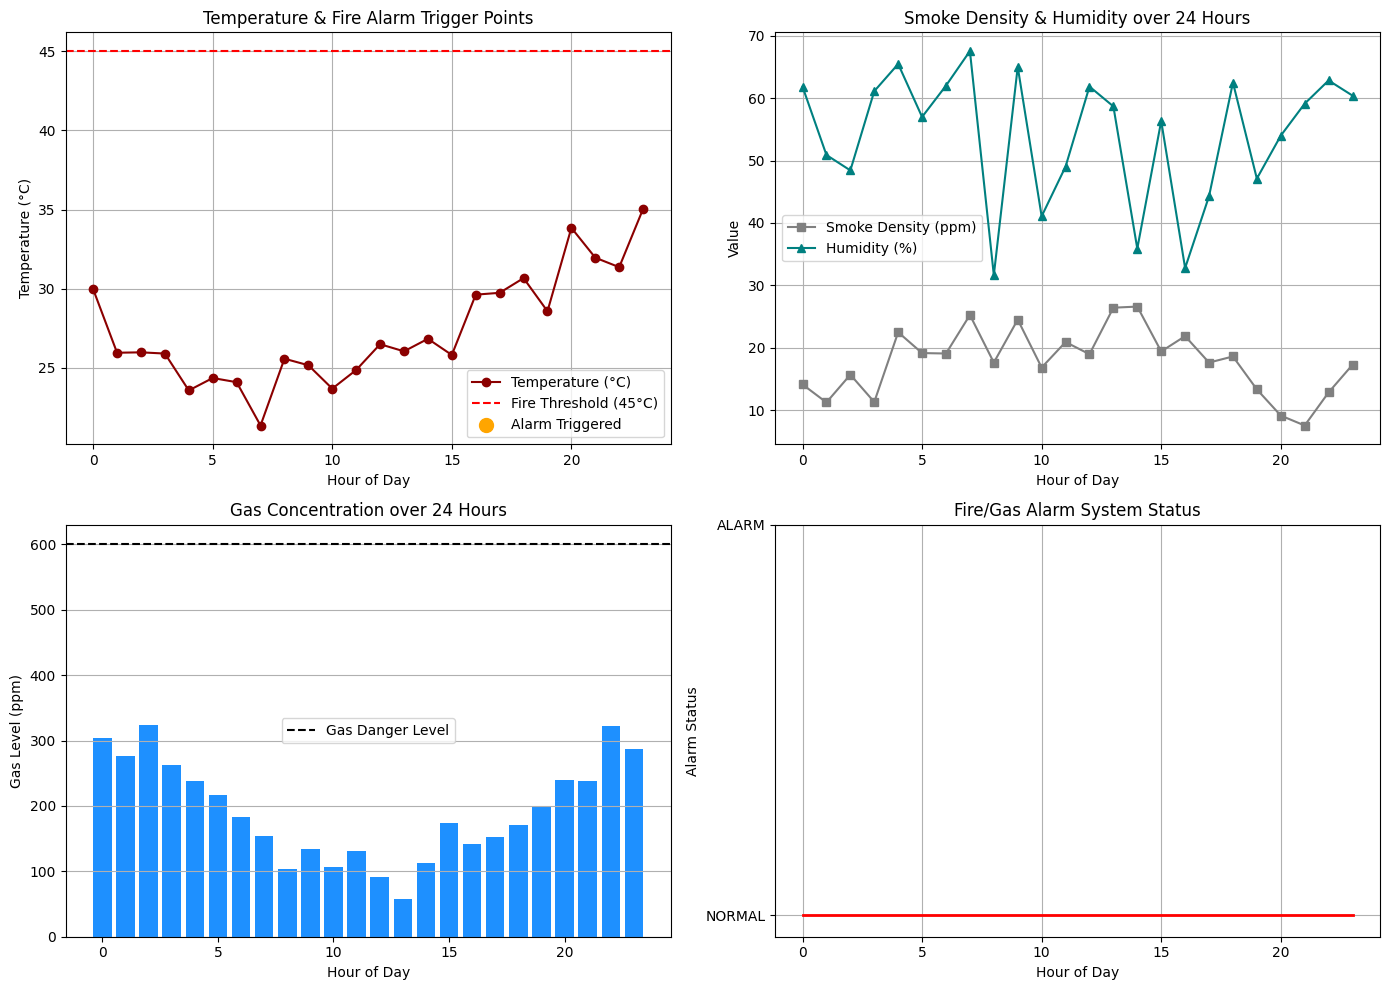


Dataset saved as 'smart_warehouse_safety_dataset.csv'


In [1]:
# IoT-Based Smart Warehouse Fire and Gas Leak Detection System
# --------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Simulate IoT Sensor Dataset (24-hour monitoring, hourly readings)
np.random.seed(7)
hours = np.arange(0, 24)

# Simulated sensor readings
temperature   = np.clip(28 + 4*np.sin((hours-15)/5) + np.random.normal(0, 1.5, 24), 20, 65)   # °C
smoke_density = np.clip(15 + 8*np.cos((hours-10)/6) + np.random.normal(0, 3, 24), 0, 100)      # ppm
gas_level     = np.clip(200 + 100*np.sin((hours-18)/4) + np.random.normal(0, 25, 24), 50, 900) # ppm (LPG/CO)
humidity      = np.random.uniform(30, 70, 24)                                                   # %

# Step 2: Automated Alarm & Suppression Decision Logic
# Rule: Alarm ON if temperature > 45°C OR smoke > 60 ppm OR gas > 600 ppm
alarm_status = []
for temp, smoke, gas in zip(temperature, smoke_density, gas_level):
    if temp > 45 or smoke > 60 or gas > 600:
        alarm_status.append(1)   # Alarm ON / Sprinkler Triggered
    else:
        alarm_status.append(0)   # Normal

df = pd.DataFrame({
    'Hour': hours,
    'Temperature(C)': temperature.round(2),
    'Smoke_Density(ppm)': smoke_density.round(2),
    'Gas_Level(ppm)': gas_level.round(1),
    'Humidity(%)': humidity.round(1),
    'Alarm_Status': alarm_status
})

print("===== IoT Smart Warehouse Safety Sensor Dataset =====\n")
print(df.to_string(index=False))

alarm_hours = df['Alarm_Status'].sum()
avg_gas = df['Gas_Level(ppm)'].mean()
print(f"\nTotal hours Alarm/Sprinkler Triggered: {alarm_hours} hrs")
print(f"Average gas concentration over 24h : {avg_gas:.2f} ppm")

# Step 3: Visualization
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# (a) Temperature with threshold and alarm markers
axs[0, 0].plot(hours, temperature, marker='o', color='darkred', label='Temperature (°C)')
axs[0, 0].axhline(45, color='red', linestyle='--', label='Fire Threshold (45°C)')
alarm_hrs = df[df['Alarm_Status'] == 1]['Hour']
alarm_temp = df[df['Alarm_Status'] == 1]['Temperature(C)']
axs[0, 0].scatter(alarm_hrs, alarm_temp, color='orange', s=100, zorder=5, label='Alarm Triggered')
axs[0, 0].set_title('Temperature & Fire Alarm Trigger Points')
axs[0, 0].set_xlabel('Hour of Day')
axs[0, 0].set_ylabel('Temperature (°C)')
axs[0, 0].legend()
axs[0, 0].grid(True)

# (b) Smoke Density and Humidity trends
axs[0, 1].plot(hours, smoke_density, marker='s', color='gray', label='Smoke Density (ppm)')
axs[0, 1].plot(hours, humidity, marker='^', color='teal', label='Humidity (%)')
axs[0, 1].set_title('Smoke Density & Humidity over 24 Hours')
axs[0, 1].set_xlabel('Hour of Day')
axs[0, 1].set_ylabel('Value')
axs[0, 1].legend()
axs[0, 1].grid(True)

# (c) Gas level bar chart
axs[1, 0].bar(hours, gas_level, color=['red' if g > 600 else 'dodgerblue' for g in gas_level])
axs[1, 0].axhline(600, color='black', linestyle='--', label='Gas Danger Level')
axs[1, 0].set_title('Gas Concentration over 24 Hours')
axs[1, 0].set_xlabel('Hour of Day')
axs[1, 0].set_ylabel('Gas Level (ppm)')
axs[1, 0].legend()
axs[1, 0].grid(True, axis='y')

# (d) Alarm ON/OFF status timeline
axs[1, 1].step(hours, alarm_status, where='mid', color='red', linewidth=2)
axs[1, 1].fill_between(hours, alarm_status, step='mid', alpha=0.3, color='red')
axs[1, 1].set_title('Fire/Gas Alarm System Status')
axs[1, 1].set_xlabel('Hour of Day')
axs[1, 1].set_ylabel('Alarm Status')
axs[1, 1].set_yticks([0, 1])
axs[1, 1].set_yticklabels(['NORMAL', 'ALARM'])
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Step 4: Save dataset as CSV (optional download in Colab)
df.to_csv('smart_warehouse_safety_dataset.csv', index=False)
print("\nDataset saved as 'smart_warehouse_safety_dataset.csv'")